# 2100 prediction model (same params) + SHAP

- **Params**: same best_params as `predict_2100_bootstrap.ipynb`
- Train: Year≤2014, single XGBoost
- SHAP: TreeExplainer for importance and contributions
- Requires: `pip install shap`

In [1]:
import pandas as pd
import numpy as np
import os
from sklearn.metrics import r2_score
import xgboost as xgb
import shap

base_dir = r'C:\Users\xyz19\OneDrive\デスクトップ\予測モデルデータセット'
os.chdir(base_dir)

regressionDF = pd.read_excel(os.path.join(base_dir, 'regression_df_20260112_233447.xlsx'))
print(f"Regression data: {regressionDF.shape}")
print(f"Year range: {regressionDF['Year'].min()} - {regressionDF['Year'].max()}")

回帰データ: (16388, 8)
Year範囲: 1961 - 2013


In [8]:
# Feature build (same as predict_2100_bootstrap)
climate_features = ['SPEI', 'GSL', 'Hurs', 'TXX']
area_dummies = pd.get_dummies(regressionDF['Area'], prefix='Area')
item_dummies = pd.get_dummies(regressionDF['Item'], prefix='Item')
year_feature = regressionDF[['Year']].copy()

X = pd.concat([
    regressionDF[climate_features],
    area_dummies,
    item_dummies,
    year_feature
], axis=1)
y = regressionDF['Yield'].copy()

train_mask = regressionDF['Year'] <= 2014
X_train = X.loc[train_mask].astype(np.float64)
y_train = y.loc[train_mask]

train_areas = sorted(regressionDF.loc[train_mask, 'Area'].unique().tolist())
train_items = sorted(regressionDF.loc[train_mask, 'Item'].unique().tolist())
feature_cols = X_train.columns.tolist()

best_params = {
    'colsample_bytree': 1.0,
    'learning_rate': 0.2,
    'max_depth': 5,
    'n_estimators': 300,
    'subsample': 0.9,
    'random_state': 42,
    'n_jobs': -1
}

print(f"Train: Year<=2014, n={train_mask.sum()}")
print(f"Areas: {len(train_areas)}, Items: {len(train_items)}")
print(f"X cols: {X.shape[1]}")

訓練: Year<=2014, n=16388
Area数: 156, Item数: 3
X列数: 164


In [9]:
# Train single model (no bootstrap)
model = xgb.XGBRegressor(**best_params)
model.fit(X_train, y_train)

y_pred = model.predict(X_train)
r2 = r2_score(y_train, y_pred)
print(f"Train R2: {r2:.4f}")

訓練 R2: 0.9624


## SHAP computation

- TreeExplainer on full training data (XGBoost is fast for tree models).

In [10]:
# SHAP TreeExplainer (XGBoost)
# Use X_train.sample(2000) if full data is too heavy
explainer = shap.TreeExplainer(model, X_train)
shap_values = explainer.shap_values(X_train)

print("SHAP values shape:", np.array(shap_values).shape)
print("Baseline (expected value):", explainer.expected_value)

 99%|===================| 16271/16388 [01:00<00:00]        

SHAP値 shape: (16388, 164)
ベースライン（期待値）: 2320.647663274356


### Global importance (mean |SHAP| per feature)

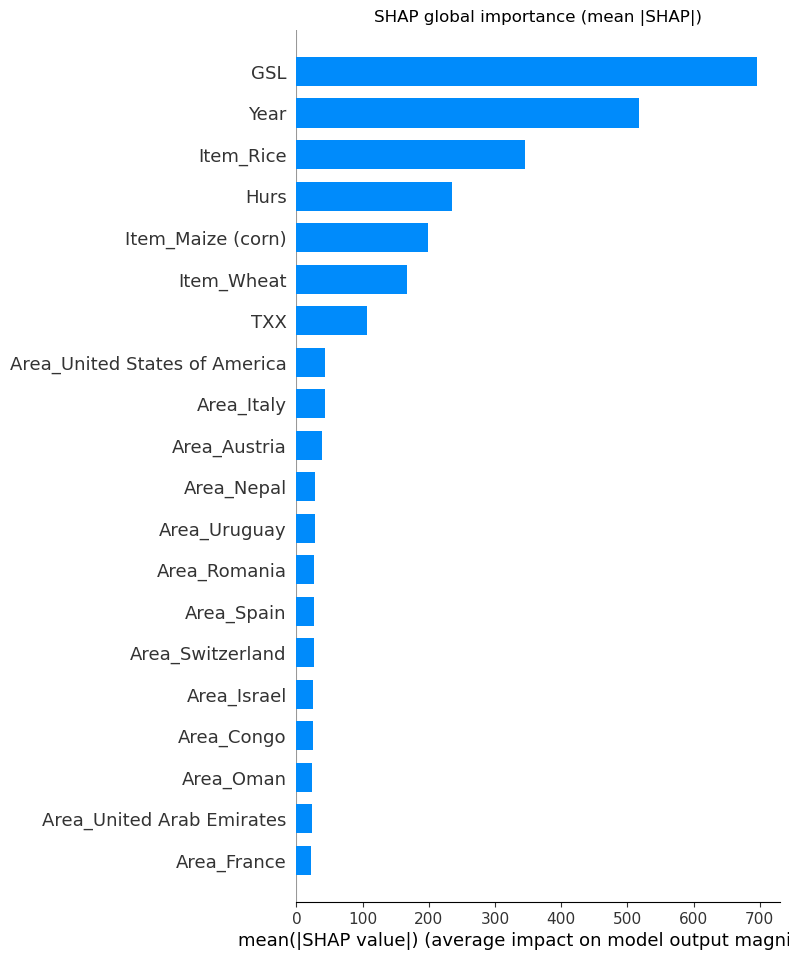

In [ ]:
import matplotlib.pyplot as plt
shap.summary_plot(shap_values, X_train, plot_type='bar', show=False)
plt.tight_layout()
plt.title('SHAP global importance (mean |SHAP|)')
plt.show()

### Summary plot (feature value vs SHAP contribution)

Top features only for readability.

### Top 7 + others total (horizontal bar)

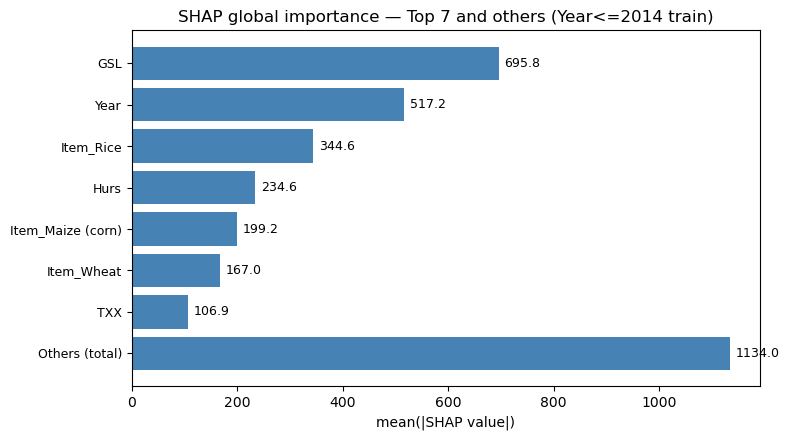

In [24]:
# Top 7 + others (total) horizontal bar (Year<=2014 train)
imp = pd.Series(mean_abs_shap, index=feature_cols).sort_values(ascending=False)
top7_vals = imp.head(7).values
top7_names = imp.head(7).index.tolist()
other_val = imp.iloc[7:].sum()
names = top7_names + ['Others (total)']
vals = np.concatenate([top7_vals, [other_val]])
fig, ax = plt.subplots(figsize=(8, 4.5))
y_pos = np.arange(len(names))[::-1]
bars = ax.barh(y_pos, vals, color='steelblue')
ax.set_yticks(y_pos)
ax.set_yticklabels(names, fontsize=9)
ax.set_xlabel('mean(|SHAP value|)')
ax.set_title('SHAP global importance — Top 7 and others (Year<=2014 train)')
for i, v in enumerate(vals):
    ax.text(v + (np.max(vals) * 0.01), y_pos[i], f'{v:.1f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

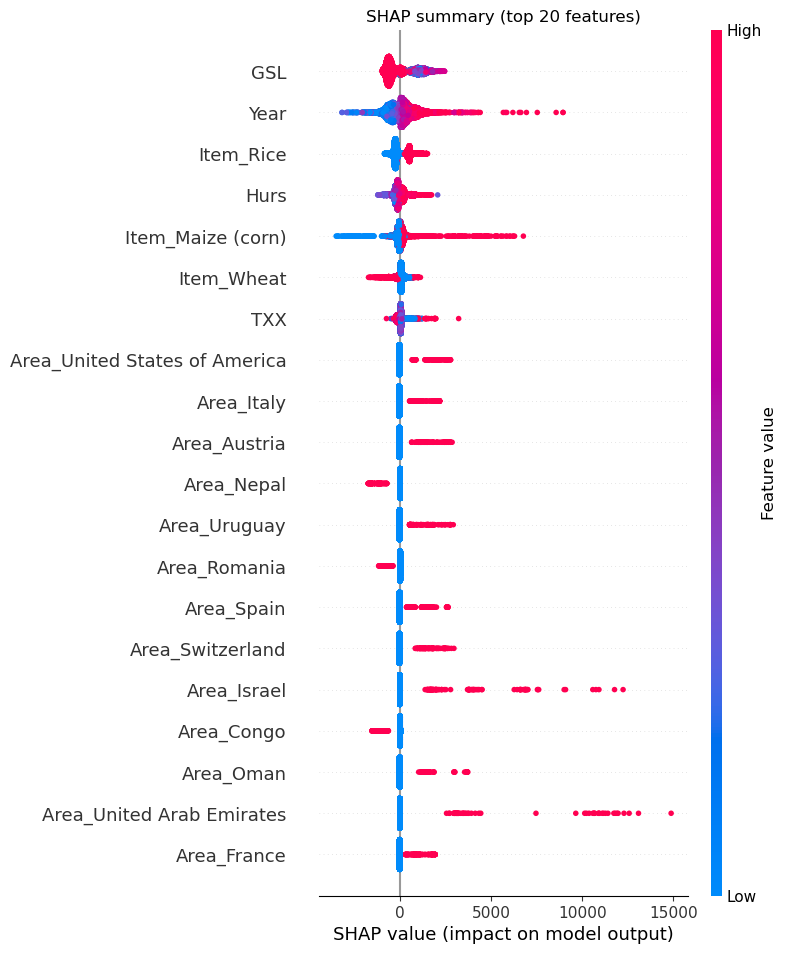

In [ ]:
# Top features by mean |SHAP|
mean_abs_shap = np.abs(shap_values).mean(axis=0)
order = np.argsort(mean_abs_shap)[::-1]
top_k = 20  # show top 20 features
top_idx = order[:top_k]
top_cols = [feature_cols[i] for i in top_idx]

import matplotlib.pyplot as plt
shap.summary_plot(
    shap_values[:, top_idx],
    X_train[top_cols],
    feature_names=top_cols,
    show=False
)
plt.tight_layout()
plt.title(f'SHAP summary (top {top_k} features)')
plt.show()

In [ ]:
# Save SHAP DataFrame (optional)
shap_df = pd.DataFrame(shap_values, columns=feature_cols)
shap_df.insert(0, 'base_value', explainer.expected_value)
out_path = os.path.join(base_dir, 'shap_values_train_predict2100_model.csv')
shap_df.to_csv(out_path, index=False)
print(f"Saved: {out_path}")

# Top 7 table (numeric)
imp = pd.Series(mean_abs_shap, index=feature_cols).sort_values(ascending=False)
top7 = imp.head(7)
tbl = pd.DataFrame({
    'Rank': range(1, 8),
    'Feature': top7.index.tolist(),
    'mean|SHAP|': top7.values.round(4)
})
tbl['Share (%)'] = (top7.values / top7.sum() * 100).round(2)
print("Top 7 features (Year<=2014 train):")
display(tbl)

## Train up to 2008, predict 2009+

Same best_params; **train: Year<=2008, test: Year>=2009**; report validation R2 and SHAP.

In [ ]:
# Train up to 2008, test 2009+
train_mask_2008 = regressionDF['Year'] <= 2008
test_mask_2009 = regressionDF['Year'] >= 2009

X_train_2008 = X.loc[train_mask_2008].astype(np.float64)
y_train_2008 = y.loc[train_mask_2008]
X_test_2009 = X.loc[test_mask_2009].astype(np.float64)
y_test_2009 = y.loc[test_mask_2009]

model_2008 = xgb.XGBRegressor(**best_params)
model_2008.fit(X_train_2008, y_train_2008)

y_pred_2009 = model_2008.predict(X_test_2009)
r2_train_2008 = r2_score(y_train_2008, model_2008.predict(X_train_2008))
r2_test_2009 = r2_score(y_test_2009, y_pred_2009)
print(f"Train (Year<=2008) n={len(y_train_2008)}, Train R2: {r2_train_2008:.4f}")
print(f"Valid (Year>=2009) n={len(y_test_2009)}, Valid R2: {r2_test_2009:.4f}")

Train (Year<=2008) n=14670, Train R2: 0.9621
Valid (Year>=2009) n=1718, Valid R2: 0.8278


In [26]:
# SHAP (train up to 2008)
explainer_2008 = shap.TreeExplainer(model_2008, X_train_2008)
shap_values_2008 = explainer_2008.shap_values(X_train_2008)
print("SHAP values shape:", np.array(shap_values_2008).shape)
print("Baseline (expected value):", explainer_2008.expected_value)

 98%|===================| 14426/14670 [00:51<00:00]        

SHAP values shape: (14670, 164)
Baseline (expected value): 2490.313292424502


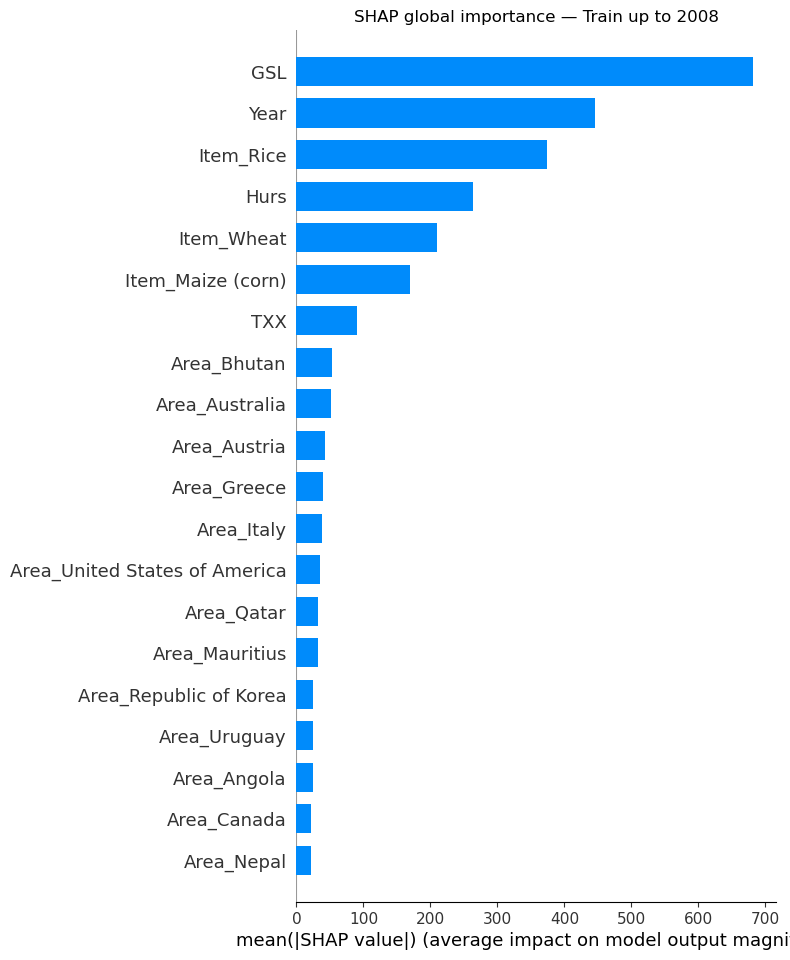

In [28]:
import matplotlib.pyplot as plt
shap.summary_plot(shap_values_2008, X_train_2008, plot_type='bar', show=False)
plt.tight_layout()
plt.title('SHAP global importance — Train up to 2008')
plt.show()

### Top 7 + others total (horizontal bar) — Train up to 2008

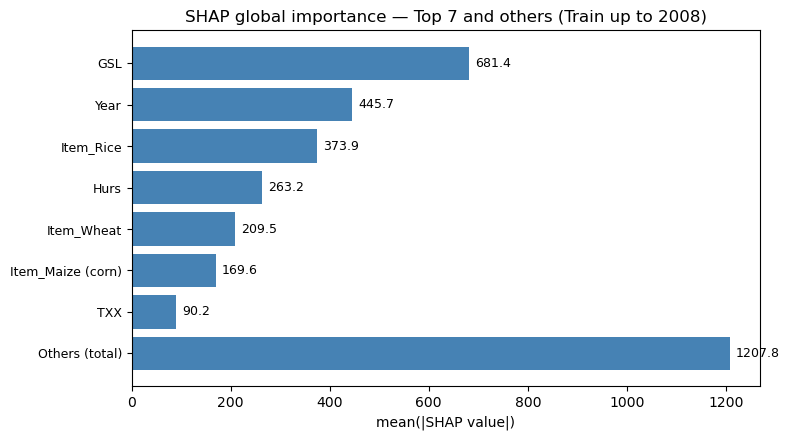

In [29]:
# Top 7 + others (total) horizontal bar (Train up to 2008)
imp_2008 = pd.Series(mean_abs_shap_2008, index=feature_cols).sort_values(ascending=False)
top7_2008_vals = imp_2008.head(7).values
top7_2008_names = imp_2008.head(7).index.tolist()
other_2008_val = imp_2008.iloc[7:].sum()
names_2008 = top7_2008_names + ['Others (total)']
vals_2008 = np.concatenate([top7_2008_vals, [other_2008_val]])
fig, ax = plt.subplots(figsize=(8, 4.5))
y_pos = np.arange(len(names_2008))[::-1]
ax.barh(y_pos, vals_2008, color='steelblue')
ax.set_yticks(y_pos)
ax.set_yticklabels(names_2008, fontsize=9)
ax.set_xlabel('mean(|SHAP value|)')
ax.set_title('SHAP global importance — Top 7 and others (Train up to 2008)')
for i, v in enumerate(vals_2008):
    ax.text(v + (np.max(vals_2008) * 0.01), y_pos[i], f'{v:.1f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

c:\Users\xyz19\anaconda3\envs\xgb-gpu\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 24180 (\N{CJK UNIFIED IDEOGRAPH-5E74}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\xyz19\anaconda3\envs\xgb-gpu\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 12414 (\N{HIRAGANA LETTER MA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\xyz19\anaconda3\envs\xgb-gpu\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 12391 (\N{HIRAGANA LETTER DE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\xyz19\anaconda3\envs\xgb-gpu\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 23398 (\N{CJK UNIFIED IDEOGRAPH-5B66}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\xyz19\anaconda3\envs\xgb-gpu\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 32722 (\N{CJK UNIFIED

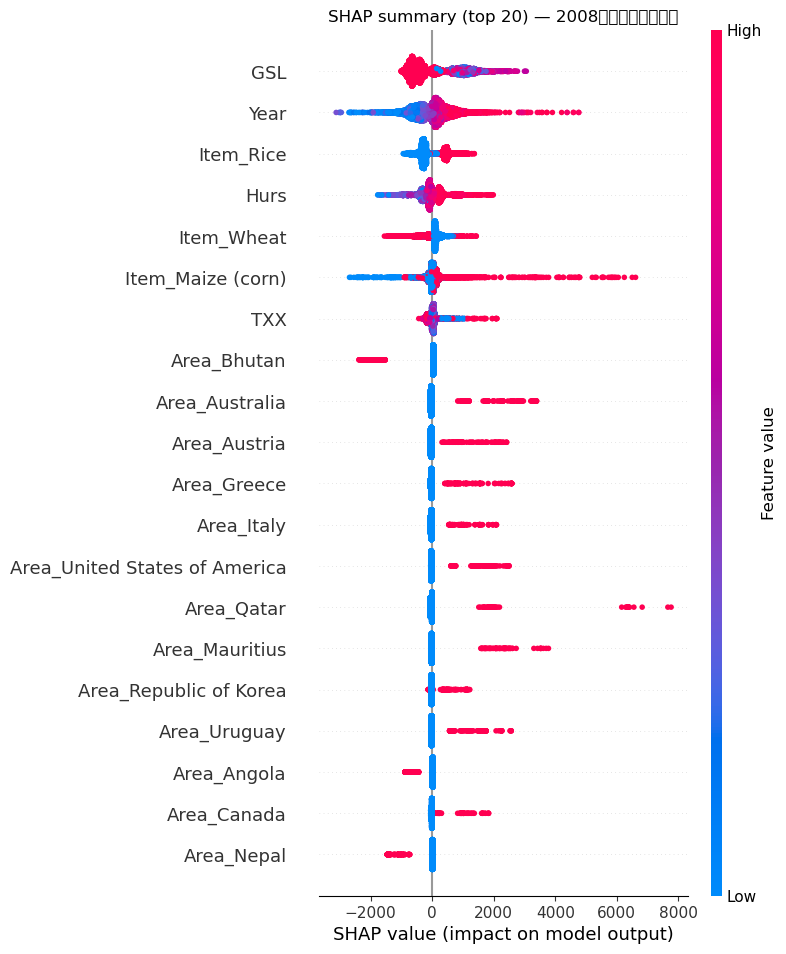

In [17]:
# Top 20 summary plot (2008 model)
mean_abs_shap_2008 = np.abs(shap_values_2008).mean(axis=0)
order_2008 = np.argsort(mean_abs_shap_2008)[::-1]
top_k = 20
top_idx_2008 = order_2008[:top_k]
top_cols_2008 = [feature_cols[i] for i in top_idx_2008]
import matplotlib.pyplot as plt
shap.summary_plot(shap_values_2008[:, top_idx_2008], X_train_2008[top_cols_2008], feature_names=top_cols_2008, show=False)
plt.tight_layout()
plt.title(f'SHAP summary (top {top_k}) — Train up to 2008')
plt.show()

In [21]:
# Save SHAP and importance (2008 model)
shap_df_2008 = pd.DataFrame(shap_values_2008, columns=feature_cols)
shap_df_2008.insert(0, 'base_value', explainer_2008.expected_value)
out_path_2008 = os.path.join(base_dir, 'shap_values_train2008_model.csv')
shap_df_2008.to_csv(out_path_2008, index=False)
print(f"Saved: {out_path_2008}")

# Top 7 table (numeric)
imp_2008 = pd.Series(mean_abs_shap_2008, index=feature_cols).sort_values(ascending=False)
top7_2008 = imp_2008.head(7)
tbl_2008 = pd.DataFrame({
    'Rank': range(1, 8),
    'Feature': top7_2008.index.tolist(),
    'mean|SHAP|': top7_2008.values.round(4)
})
tbl_2008['Share (%)'] = (top7_2008.values / top7_2008.sum() * 100).round(2)
print("Top 7 features (Train up to 2008):")
display(tbl_2008)

保存: C:\Users\xyz19\OneDrive\デスクトップ\予測モデルデータセット\shap_values_train2008_model.csv
重要度上位7特徴量（2008年まで学習モデル）:


,順位,特徴量,平均|SHAP|,割合(%)
0,1,GSL,681.3621,30.51
1,2,Year,445.6554,19.95
2,3,Item_Rice,373.8675,16.74
3,4,Hurs,263.2265,11.79
4,5,Item_Wheat,209.4730,9.38
5,6,Item_Maize (corn),169.5643,7.59
6,7,TXX,90.1946,4.04
